In [47]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image
from typing import TypedDict
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI


In [ ]:

load_dotenv("../../../LangChainModels/.env") # Load environment variables from .env file

True

In [49]:
class State(TypedDict):
    question: str
    answer: str

In [50]:
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

In [51]:
def llm_qna(state: State) -> State:
    question = state["question"]
    prompt = f"Answer the following question: {question}"
    answer = llm.invoke(prompt).content
    state["answer"] = answer
    return state


In [52]:
graph = StateGraph(State)

In [53]:
#defining nodes
graph.add_node("LLM QnA", llm_qna)

In [54]:
#designing edges
graph.add_edge(START, "LLM QnA")
graph.add_edge("LLM QnA", END)

In [55]:
#compiling the graph
app= graph.compile()
user_input = input("Enter your question: ")

In [56]:
result = app.invoke({
    'question': user_input,
    'answer' : " "
})

In [57]:
print(result)

{'question': 'what is capital of india', 'answer': 'The capital of India is New Delhi.'}


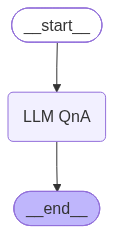

In [58]:
Image(app.get_graph().draw_mermaid_png())